In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
N = 100
folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026"
file = r"J_1_12.06.2026_13_05_36.csv"
file_path = os.path.join(folder_path, file)
df = pd.read_csv(file_path)
print(df.shape)
df.head()

(47265, 25)


,timestamp,m_t_1,m_t_2,m_t_3,m_t_4,m_t_5,m_t_6,jts1,jts2,jts3,...,v3,v4,v5,v6,q1,q2,q3,q4,q5,q6
0,13:05:36.309097,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
1,13:05:36.314152,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
2,13:05:36.319315,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
3,13:05:36.324284,0.01647,-0.00549,-0.0,0.01003,-0.0059,0.02065,0.553648,0.337786,-0.00015,...,-0.054,-0.006,-0.006,-0.018,0.000687,-0.002060,0.006866,-0.000000,0.001373,-0.000687
4,13:05:36.329277,0.01647,-0.00549,-0.0,0.01003,-0.0059,0.02065,0.553648,0.337786,-0.00015,...,-0.054,-0.006,-0.006,-0.018,0.000687,-0.002060,0.006866,-0.000000,0.001373,-0.000687


In [ ]:
df["timestamp"] = pd.to_datetime("2026-06-12 " + df["timestamp"].astype(str))
df["q"] = np.deg2rad(df["q1"])
df["v"] = np.deg2rad(df["v1"])
df["tm"] = df["m_t_1"]
df["tj"] = df["jts1"]
df["tf"] = (N * df["tm"] - df["tj"])

In [ ]:
X = df[["q", "v"]].values
y = df["tf"].values

In [ ]:
n_samples = len(df)
X_train, X_test, y_train, y_test = train_test_split()
X_train = X[: train_end]
X_val = X[train_end : val_end]
X_test = X[val_end :]
y_train = y[: train_end]
y_val = y[train_end : val_end]
y_test = y[val_end :]
test_time = df["timestamp"].iloc[val_end :]

In [ ]:
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_val = x_scaler.transform(X_val)
X_test = x_scaler.transform(X_test)

In [ ]:
model = Sequential([
    Dense(64, activation='tanh', input_shape=(2,)),
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(1)
])
model.summary()

c:\Users\HP\.conda\envs\csirinternshipenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,465 (25.25 KB)

 Trainable params: 6,465 (25.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
early_stop = EarlyStopping(
    patience=20,
    restore_best_weights=True
)
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 225.9356 - val_loss: 135.2843
Epoch 2/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 100.3836 - val_loss: 89.5402
Epoch 3/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 67.0134 - val_loss: 62.8275
Epoch 4/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 45.9108 - val_loss: 44.8178
Epoch 5/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.8311 - val_loss: 32.4619
Epoch 6/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 22.6230 - val_loss: 24.3347
Epoch 7/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 16.6653 - val_loss: 19.0684
Epoch 8/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13.0078 - val_loss: 15.6039
Epoch 9/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 10.7950 - val_loss: 13.4576
Epoch 10/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.4497 - val_loss: 11.9425
Epoch 11/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.4581 - val_loss: 10.6116
Epoch 12/500
56/56 ━━━━━━━━━━━━━━━━━━━━ 

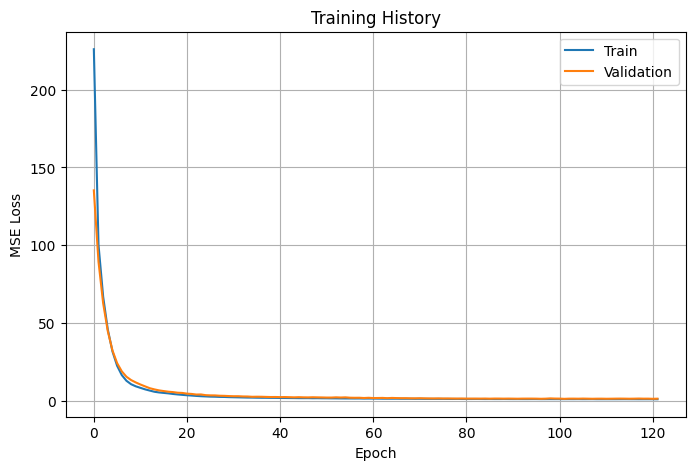

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(
    history.history["loss"],
    label="Train"
)
plt.plot(
    history.history["val_loss"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training History")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
pred0 = model.predict(X_test).flatten()

296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step


In [ ]:
rmse0 = np.sqrt(mean_squared_error(y_test, pred0))
mae0 = mean_absolute_error(y_test, pred0)
r2_0 = r2_score(y_test, pred0)
print("RMSE =", rmse0)
print("MAE =", mae0)
print("R2 =", r2_0)

RMSE = 1.3621420674939635
MAE = 1.0237070282624747
R2 = 0.9952515618313704


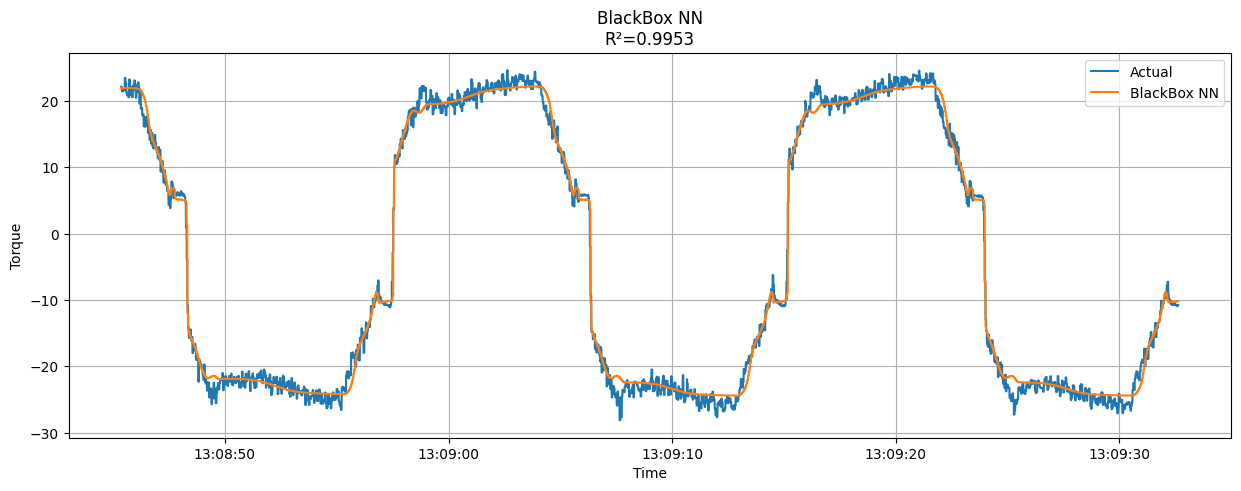

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(
    test_time,
    y_test,
    label="Actual"
)
plt.plot(
    test_time,
    pred0,
    label="BlackBox NN"
)
plt.xlabel("Time")
plt.ylabel("Torque")
plt.title(f"BlackBox NN\nR²={r2_0:.4f}")
plt.legend()
plt.grid(True)
plt.show()

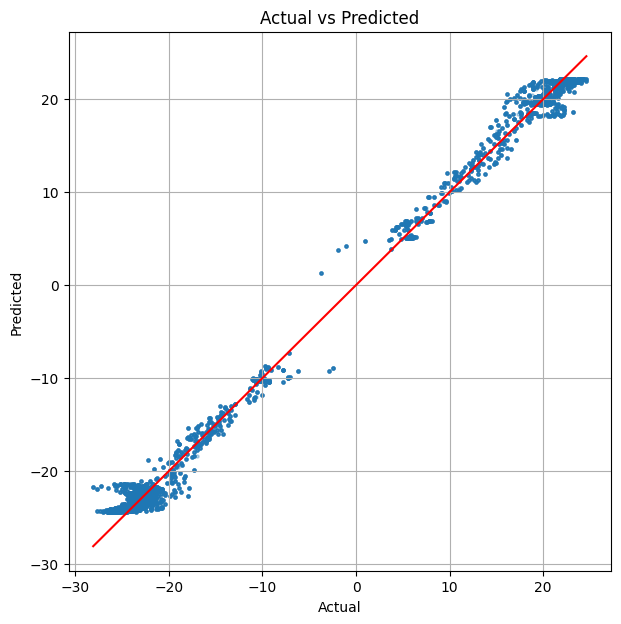

In [ ]:
plt.figure(figsize=(7,7))
plt.scatter(
    y_test,
    pred0,
    s=5,
    alpha=0.3
)
min_val = min(
    y_test.min(),
    pred0.min()
)
max_val = max(
    y_test.max(),
    pred0.max()
)
plt.plot(
    [min_val,max_val],
    [min_val,max_val],
    'r'
)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.grid(True)
plt.show()

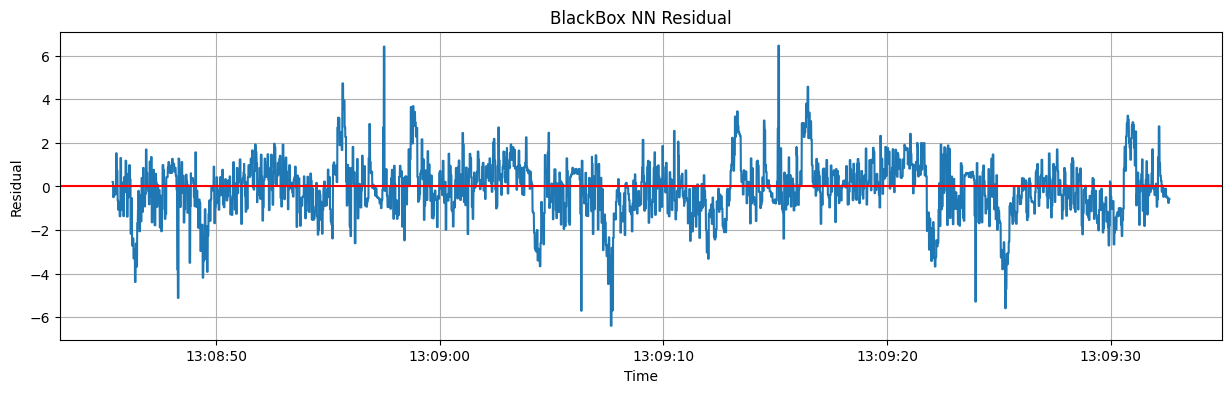

In [ ]:
residual4 = (y_test - pred0)
plt.figure(figsize=(15,4))
plt.plot(
    test_time,
    residual4
)
plt.axhline(
    0,
    color='red'
)
plt.xlabel("Time")
plt.ylabel("Residual")
plt.title("BlackBox NN Residual")
plt.grid(True)
plt.show()

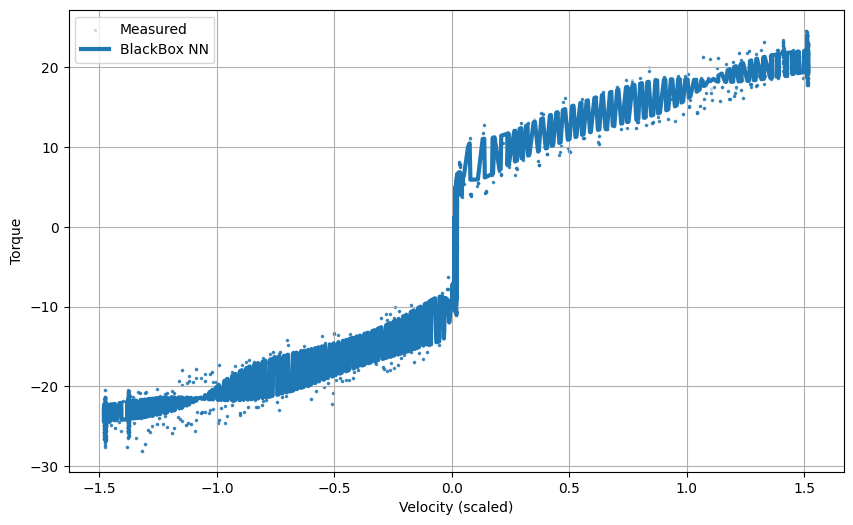

In [ ]:
v_test = X_test[ :, 1]
idx = np.argsort(v_test)
plt.figure(figsize=(10,6))
plt.scatter(
    v_test,
    y_test,
    s=2,
    alpha=0.2,
    label="Measured"
)
plt.plot(
    v_test[idx],
    pred0[idx],
    linewidth=3,
    label="BlackBox NN"
)
plt.xlabel("Velocity (scaled)")
plt.ylabel("Torque")
plt.legend()
plt.grid(True)
plt.show()